In [6]:
import requests
import json

from google.colab import userdata

# API Test Portfolio
api_key = userdata.get('test_key')
portfolio_id = "c4867cd8-d9b4-5188-a092-5b881d841830"

url = f"https://api.securityscorecard.io/portfolios/{portfolio_id}/companies"
print(url)

headers = {
    "accept": "application/json; charset=utf-8",
    "Authorization": f"Token {api_key}"
}

response = requests.get(url, headers=headers)

json_data = response.json()

entries = json_data["entries"]
print("{:<25} {:<25} {:<10} {:<5}".format("Name", "Domain", "Score", "Grade"))
print("-" * 70) # Separator line

# Go through each company from our response
for entry in entries:
    name = entry["name"]
    domain = entry["domain"]
    score = entry["score"]
    grade = entry["grade"]
    # print out the current company
    print("{:<25} {:<25} {:<10} {:<5}".format(name, domain, score, grade))

https://api.securityscorecard.io/portfolios/c4867cd8-d9b4-5188-a092-5b881d841830/companies
Name                      Domain                    Score      Grade
----------------------------------------------------------------------
Amazon AWS                amazonaws.com             77         C    
Google Services           gmail.com                 54         F    
Datadog                   datadoghq.com             91         A    
Microsoft Azure           azure.com                 53         F    
Oracle Cloud              oraclecloud.com           79         C    


In [9]:
def get_all_third_party_vendors(domain, headers=None, limit=500):
  all_entries = []
  page = 1

  while True:
    url = f"https://api.securityscorecard.io/vendor-detection/{domain}/third-party?page={page}&limit={limit}"

    response = requests.get(url, headers=headers)

    data = response.json()

    if data['size'] == 0:
      break

    all_entries.extend(data['entries'])
    page += 1

  return all_entries


# print out results to see if this function works as intended
# recall our entries (domains) we retrieved in the last step
for entry in entries:
    domain = entry["domain"]
    third_party_vendors = get_all_third_party_vendors(domain, headers=headers)

    if third_party_vendors:
        print(f"Found {len(third_party_vendors)} third-party vendors for {domain}.")
        # Process the third_party_vendors list here (e.g., print, save to file)
        # Example print of first 3 results.
        if len(third_party_vendors) > 0:
          print("Example first 3 results:")
          for i in range(min(3, len(third_party_vendors))):
            print(third_party_vendors[i])
    else:
        print(f"No third-party vendors found for {domain} or error occurred.")

Found 43 third-party vendors for amazonaws.com.
Example first 3 results:
{'domain': 'adobe.com', 'industry': 'technology', 'company': 'Adobe', 'source': 'HTTP requests', 'connection_detail': 'https://pay.amazon.com/ calls GET - amazonservices1.sc.omtrdc.net/b/ss/amznpaymentsglobalprod/1/JS-2.22.3-LEWM/s79818882209936?AQB=1&ndh=1&pf=1&t=24%2F3%2F2025%203%3A9%3A54%204%200&mid=68739420695758302812465029373536137136&aamlh=7&ce=UTF-8&pageName=amznpay%3Aus%3Ahome&g=https%3A%2F%2Fpay.amazon.com%2F&c.&apl=4.0&getTimeParting=6.3&.c&cc=USD&events=event1&aamb=6G1ynYcLPuiQxYZrsz_pkqfLG9yMXBpb2zX5dvJdYQJzPXImdj0y&c1=D%3Dv1&v1=amznpay%3Aus%3Ahome&c2=D%3Dv2&v2=https%3A%2F%2Fpay.amazon.com%2F&c5=D%3Dv6&v5=year%3D2025%20%7C%20month%3DApril%20%7C%20date%3D23%20%7C%20day%3DWednesday%20%7C%20time%3D8%3A09%20PM&c6=D%3Dv7&v6=pay.amazon.com&v7=68739420695758302812465029373536137136&s=800x600&c=24&j=1.6&v=N&k=Y&bw=780&bh=441&mcorgid=A7493BC75245ACD20A490D4D%40AdobeOrg&AQE=1 /200', 'observed': '2025-04-24T03:0

In [11]:
from collections import defaultdict

# key: vendor domain
# data:
#.    - vendor_domain (the domain of the vendor we are storing information for)
#.    - count (how many times did this vendor domain come up?)
#.    - domains (the list of portfolio domains that our vendor was found in)

vendor_counts = defaultdict(lambda: {"count": 0, "domains": [], "vendor_domain": None})

for entry in entries:
  domain = entry["domain"]

  third_party_vendors = get_all_third_party_vendors(domain, headers=headers)

  if third_party_vendors:
    for vendor in third_party_vendors:
      vendor_name = vendor["company"] # store the company name (Apple Inc)
      vendor_domain = vendor["domain"] # store the domain (apple.com)

      vendor_counts[vendor_name]["count"] += 1 # increment the count in our vendor_counts for this specific domain
      vendor_counts[vendor_name]["domains"].append(domain) # add the portfolio domain to the list of companies with this specific vendor
      vendor_counts[vendor_name]["vendor_domain"] = vendor_domain  # Store 3rd party vendor domain in our list of vendors

sorted_vendors_third_party = sorted(vendor_counts.items(), key=lambda item: item[1]["count"], reverse=True)

print("{:<8} {:<30} {:<30} {}".format("Count", "Company", "Vendor Domain", "List of Companies with Vendor"))
print("-" * 120)

for vendor_name, data in sorted_vendors_third_party:
    if data['count'] > 3:  # Check if count is greater than threshold number
        domains_str = ", ".join(data['domains'])
        vendor_domain_str = str(data['vendor_domain']) if data['vendor_domain'] is not None else "N/A"
        vendor_name_str = str(vendor_name) if vendor_name is not None else "N/A"
        print("{:<8} {:<30} {:<30} {}".format(data['count'], vendor_name_str, vendor_domain_str, domains_str))

Count    Company                        Vendor Domain                  List of Companies with Vendor
------------------------------------------------------------------------------------------------------------------------
7        Adobe                          adobe.com                      amazonaws.com, amazonaws.com, gmail.com, gmail.com, datadoghq.com, datadoghq.com, oraclecloud.com
5        Amazon                         amazon.com                     amazonaws.com, gmail.com, datadoghq.com, azure.com, oraclecloud.com
5        Google                         google.com                     amazonaws.com, gmail.com, datadoghq.com, azure.com, oraclecloud.com
5        Microsoft Corporation          microsoft.com                  amazonaws.com, gmail.com, datadoghq.com, azure.com, oraclecloud.com
5        Oracle America, Inc.           oracle.com                     amazonaws.com, gmail.com, datadoghq.com, azure.com, oraclecloud.com
4        DigitalOcean                   digitalocean.

In [12]:
# get 4th party vendors

def get_all_fourth_party_vendors(domain, headers=None, limit=500):
    """
    Retrieves all fourth-party vendors for a domain, handling pagination.

    Args:
        domain: The domain to query.
        headers: Optional headers for the request.
        limit: The number of results per page.

    Returns:
        A list containing the data from all pages.
    """

    all_entries = []
    page = 1

    while True:
        url = f"https://api.securityscorecard.io/vendor-detection/{domain}/fourth-party?page={page}&limit={limit}"
        try:
            response = requests.get(url, headers=headers)
            response.raise_for_status()  # Check for HTTP errors
            data = response.json()

            if data["size"] == 0:
                break  # Stop if no entries are returned

            all_entries.extend(data["entries"])
            page += 1  # Increment the page number

        except requests.exceptions.RequestException as e:
            print(f"Error fetching page {page}: {e}")
            break  # Stop on error
        except json.JSONDecodeError as e:
            print(f"Error decoding json on page {page}: {e}")
            break  # Stop on error decoding json.

    return all_entries

  #Example usage (printing out our results from our portfolio):
for entry in entries:
    domain = entry["domain"]
    fourth_party_vendors = get_all_fourth_party_vendors(domain, headers=headers)

    if fourth_party_vendors:
        print(f"Found {len(fourth_party_vendors)} fourth-party vendors for {domain}.")
        # Process the fourth_party_vendors list here (e.g., print, save to file)
        # Example print of first 3 results.
        if len(fourth_party_vendors) > 0:
            print("Example first 3 results:")
            for i in range(min(3, len(fourth_party_vendors))):
                print(fourth_party_vendors[i])
    else:
        print(f"No fourth-party vendors found for {domain} or error occurred.")

Found 3469 fourth-party vendors for amazonaws.com.
Example first 3 results:
{'domain': '0.com', 'industry': 'technology', 'company': '0', 'source': 'Mail exchange', 'connection_detail': 'www.jobsblog.com - 0 . - MX', 'observed': '2025-04-27T19:16:57.000Z', 'score': 100}
{'domain': '10xgenomics.com', 'industry': 'information_services', 'company': '10x Genomics, Inc.', 'source': 'Enhanced illumination', 'connection_detail': 'Job Posting', 'observed': '2025-04-10T13:37:05.000Z', 'score': 85}
{'domain': '1and1.com', 'industry': 'technology', 'company': '1and1', 'source': 'Mail exchange', 'connection_detail': 'ww1.myrampup.com - 10 mxint02.1and1.com. - MX', 'observed': '2025-04-12T18:11:57.000Z', 'score': 61}
Found 3728 fourth-party vendors for gmail.com.
Example first 3 results:
{'domain': '0.com', 'industry': 'technology', 'company': '0', 'source': 'Mail exchange', 'connection_detail': 'webvitals.com - 0 . - MX', 'observed': '2025-04-26T17:39:01.000Z', 'score': 100}
{'domain': '10xgenomic

In [13]:
# see how many overlap between 4th party

# create a similar dictionary as before
vendor_counts_fourth_party = defaultdict(lambda: {"count": 0, "domains":[], "vendor_domain": None})

for entry in entries:
    domain = entry["domain"]
    fourth_party_vendors = get_all_fourth_party_vendors(domain, headers=headers)

    # check to make sure it isn't empty
    if fourth_party_vendors:
      # iterate through all the entries in the response
        for vendor in fourth_party_vendors:
            vendor_name = vendor["company"] # store the company name (Apple Inc)
            vendor_domain = vendor.get("domain") # store the domain (apple.com)

            vendor_counts_fourth_party[vendor_name]["count"] += 1 # increment the count in our vendor_counts for this specific domain
            vendor_counts_fourth_party[vendor_name]["domains"].append(domain) # add the portfolio domain to the list of companies with this specific vendor
            vendor_counts_fourth_party[vendor_name]["vendor_domain"] = vendor_domain  # Store 4th party vendor domain in our list of vendors
    else:
        print(f"No fourth-party vendors found for {domain} or error occurred.")

# sort our dictionary by count
sorted_vendors_fourth_party = sorted(vendor_counts_fourth_party.items(), key=lambda item: item[1]["count"], reverse=True)

# print out our results as an example
print("\n--- Fourth-Party Vendor Overlap ---")
print("{:<8} {:<30} {:<30} {}".format("Count", "Company", "Vendor Domain", "List of Companies with 4th Party Vendor"))
print("-" * 120)

line_print_count = 0

for vendor_name, data in sorted_vendors_fourth_party:
    if data['count'] > 5:  # Check if count is greater than threshold number
        domains_str = ", ".join(data['domains'])
        vendor_domain_str = str(data['vendor_domain']) if data['vendor_domain'] is not None else "N/A"
        vendor_name_str = str(vendor_name) if vendor_name is not None else "N/A"
        print("{:<8} {:<30} {:<30} {}".format(data['count'], vendor_name_str, vendor_domain_str, domains_str))

        line_print_count += 1
        # optionally limit result printout size
        if line_print_count >= 20:
            break;


--- Fourth-Party Vendor Overlap ---
Count    Company                        Vendor Domain                  List of Companies with 4th Party Vendor
------------------------------------------------------------------------------------------------------------------------
30       N/A                            teamtito.com                   amazonaws.com, amazonaws.com, amazonaws.com, amazonaws.com, amazonaws.com, amazonaws.com, gmail.com, gmail.com, gmail.com, gmail.com, gmail.com, gmail.com, gmail.com, gmail.com, datadoghq.com, datadoghq.com, datadoghq.com, datadoghq.com, datadoghq.com, datadoghq.com, datadoghq.com, azure.com, azure.com, azure.com, azure.com, oraclecloud.com, oraclecloud.com, oraclecloud.com, oraclecloud.com, oraclecloud.com
13       Yandex                         yandex.ru                      amazonaws.com, amazonaws.com, amazonaws.com, gmail.com, gmail.com, gmail.com, datadoghq.com, datadoghq.com, datadoghq.com, azure.com, oraclecloud.com, oraclecloud.com, oracleclou

In [15]:
vendor_objects = []

for vendor_name, data in sorted_vendors_third_party:
  vendor_objects.append({
      "company": vendor_name,
      "domain": data['vendor_domain'],
      "third_party_count": data['count'],
      "fourth_party_count": 0  # Initialize fourth-party count to 0
  })


for vendor_name, data in sorted_vendors_fourth_party:
  found = False

  for vendor in vendor_objects:
    if vendor['company'] == vendor_name:
      vendor['fourth_party_count'] = data['count']
      found = True
      break
  if not found:
      vendor_objects.append({
        "company": vendor_name,
        "domain": data['vendor_domain'],
        "third_party_count": 0, # since it wasn't in our 3rd party list, we know this is zero
        "fourth_party_count": data['count'] # assign the 4th party data count
    })


line_print_count = 0;

# Print the new list of objects (optional)
for vendor in vendor_objects:
    if vendor.get('third_party_count', 0) > 3 or vendor.get('fourth_party_count', 0) > 3 + 2:
        print(f"Company: {vendor['company']}, Domain: {vendor['domain']}, Third Party Dependencies: {vendor['third_party_count']}, Fourth Party Dependencies: {vendor['fourth_party_count']}")

        line_print_count += 1
        # optionally limit result printout size
        if line_print_count >= 20:
            break;

Company: Adobe, Domain: adobe.com, Third Party Dependencies: 7, Fourth Party Dependencies: 10
Company: Amazon, Domain: amazon.com, Third Party Dependencies: 5, Fourth Party Dependencies: 10
Company: Google, Domain: google.com, Third Party Dependencies: 5, Fourth Party Dependencies: 5
Company: Microsoft Corporation, Domain: microsoft.com, Third Party Dependencies: 5, Fourth Party Dependencies: 5
Company: Oracle America, Inc., Domain: oracle.com, Third Party Dependencies: 5, Fourth Party Dependencies: 5
Company: DigitalOcean, Domain: digitalocean.com, Third Party Dependencies: 4, Fourth Party Dependencies: 5
Company: Facebook, Domain: facebook.com, Third Party Dependencies: 4, Fourth Party Dependencies: 5
Company: Python Software Foundation Corp, Domain: python.org, Third Party Dependencies: 4, Fourth Party Dependencies: 5
Company: Cloudflare, Inc., Domain: cloudflare.com, Third Party Dependencies: 4, Fourth Party Dependencies: 5
Company: GitHub, Domain: github.com, Third Party Dependenc

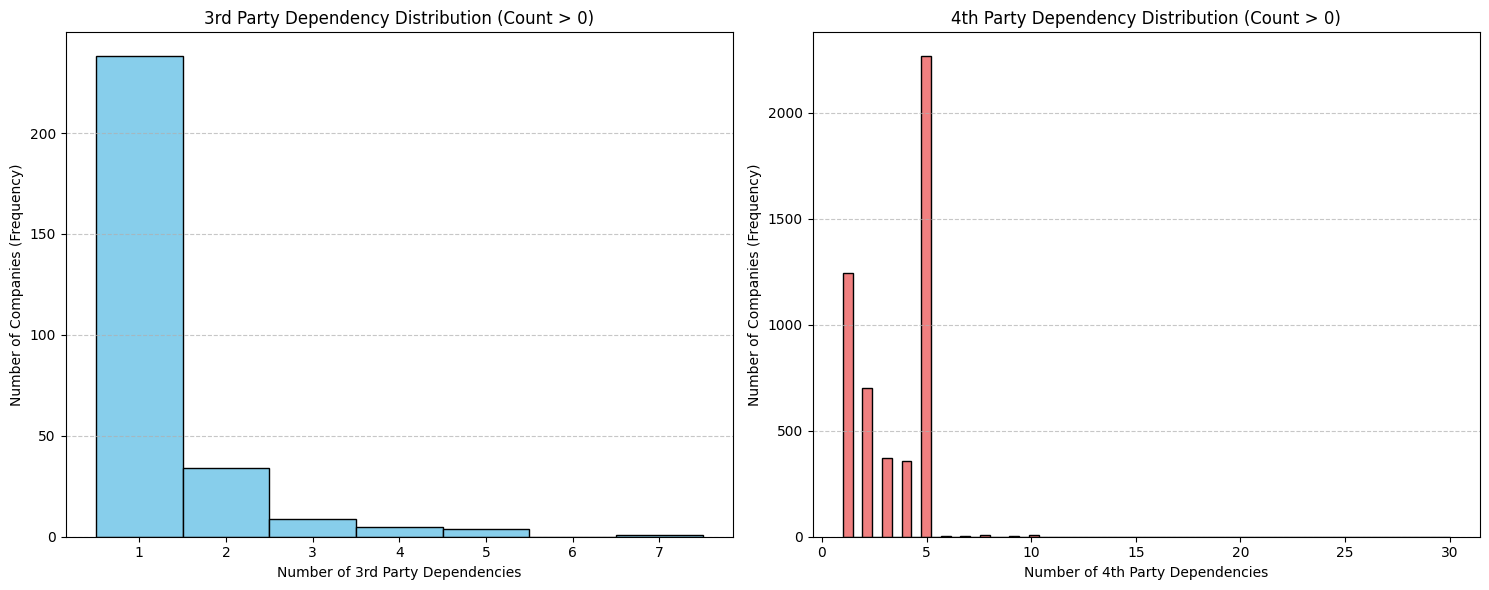


--- Frequency Counts (Excluding Dependency Count 0) ---
3rd Party Counts: (Dependency Count Value: Frequency)
  0: 4673
  1: 238
  2: 34
  3: 9
  4: 5
  5: 4
  7: 1

4th Party Counts: (Dependency Count Value: Frequency)
  0: 4
  1: 1242
  2: 701
  3: 372
  4: 355
  5: 2265
  6: 4
  7: 2
  8: 7
  9: 4
  10: 6
  13: 1
  30: 1


In [16]:
import matplotlib.pyplot as plt
import numpy as np # Used for calculating max value for simple binning
from collections import Counter # Used for simple frequency counts

# --- This code ASSUMES 'vendor_objects' list exists and is populated ---
# --- by your previous code block. It does not redefine the data. ---

# Basic check to see if vendor_objects seems to exist and has data
if 'vendor_objects' not in locals() or not isinstance(vendor_objects, list) or not vendor_objects:
    print("Error: 'vendor_objects' list not found or is empty.")
    print("Please ensure your code populating 'vendor_objects' runs successfully before this plotting code.")
else:
    # 1. Extract the dependency counts into simple lists
    all_third_party_counts = [vendor.get('third_party_count', 0) for vendor in vendor_objects]
    all_fourth_party_counts = [vendor.get('fourth_party_count', 0) for vendor in vendor_objects]

    # --- FILTER DATA: Create lists excluding zero counts for plotting ---
    third_party_counts_no_zero = [count for count in all_third_party_counts if count != 0]
    fourth_party_counts_no_zero = [count for count in all_fourth_party_counts if count != 0]
    # --- End Filtering ---

    # Check if there's any non-zero data left to plot
    if not third_party_counts_no_zero and not fourth_party_counts_no_zero:
        print("No non-zero dependency counts found to plot.")
    else:
        # 2. Create a figure with two subplots side-by-side
        fig, axes = plt.subplots(1, 2, figsize=(15, 6)) # 1 row, 2 columns

        # --- Plot 3rd Party Histogram (Excluding Zeros) ---
        if third_party_counts_no_zero: # Only plot if there's data
            max_3rd = np.max(third_party_counts_no_zero)
            # Create bins starting from 1. Edges: [0.5, 1.5, ..., max+0.5]
            bins_3rd = np.arange(1, int(max_3rd) + 2) - 0.5

            axes[0].hist(third_party_counts_no_zero, bins=bins_3rd, edgecolor='black', align='mid', color='skyblue')
            axes[0].set_title('3rd Party Dependency Distribution (Count > 0)')
            axes[0].set_xlabel('Number of 3rd Party Dependencies')
            axes[0].set_ylabel('Number of Companies (Frequency)')
            # Set ticks starting from 1
            axes[0].set_xticks(np.arange(1, int(max_3rd) + 1))
            axes[0].grid(axis='y', linestyle='--', alpha=0.7)
        else:
            axes[0].set_title('No 3rd Party Dependencies > 0 Found')
            axes[0].text(0.5, 0.5, 'No data to display', horizontalalignment='center', verticalalignment='center', transform=axes[0].transAxes)


        # --- Plot 4th Party Histogram (Excluding Zeros) ---
        if fourth_party_counts_no_zero: # Only plot if there's data
            max_4th = np.max(fourth_party_counts_no_zero)
            # Use 'auto' binning on the filtered data
            bins_4th='auto'

            axes[1].hist(fourth_party_counts_no_zero, bins=bins_4th, edgecolor='black', align='mid', color='lightcoral')
            axes[1].set_title('4th Party Dependency Distribution (Count > 0)')
            axes[1].set_xlabel('Number of 4th Party Dependencies')
            axes[1].set_ylabel('Number of Companies (Frequency)')
            axes[1].grid(axis='y', linestyle='--', alpha=0.7)
            # Note: Auto binning might still be affected by the outlier (30).
        else:
            axes[1].set_title('No 4th Party Dependencies > 0 Found')
            axes[1].text(0.5, 0.5, 'No data to display', horizontalalignment='center', verticalalignment='center', transform=axes[1].transAxes)


        # 3. Display the plots
        plt.tight_layout() # Adjust layout to prevent overlap
        plt.show()

    # --- Optional: Print Simple Frequency Counts ---
    print("\n--- Frequency Counts (Excluding Dependency Count 0) ---")
    count_3rd = Counter(all_third_party_counts) # Use original list for full count info
    count_4th = Counter(all_fourth_party_counts) # Use original list for full count info

    print("3rd Party Counts: (Dependency Count Value: Frequency)")
    for value, freq in sorted(count_3rd.items()):
          print(f"  {value}: {freq}")

    print("\n4th Party Counts: (Dependency Count Value: Frequency)")
    for value, freq in sorted(count_4th.items()):
          print(f"  {value}: {freq}")